### Reading the Spam-Ham Dataset

In [1]:
import torch
from torch.utils.data import Dataset
import tiktoken
import pandas as pd

class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.data = pd.read_csv(csv_file)
        self.encoded_texts = [tokenizer.encode(text) for text in self.data["Text"]]

        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
            self.encoded_texts = [encoded_text[:self.max_length] for encoded_text in self.encoded_texts]

        self.encoded_texts = [
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text)) for encoded_text in self.encoded_texts
        ] # Padding with the <|endoftext|> token up to the max_length

    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )
    
    def __len__(self):
        return len(self.data)
    
    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length:
                max_length = encoded_length
        return max_length
    
tokenizer = tiktoken.get_encoding("gpt2")
train_dataset = SpamDataset(
    "../data/train.csv",
    max_length=None,
    tokenizer=tokenizer
)
val_dataset = SpamDataset(
    "../data/validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)
test_dataset = SpamDataset(
    "../data/test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

In [2]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    drop_last=False
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    drop_last=False
)

In [3]:
print("Train loader:")
for input_batch, target_batch in train_loader:
    break

print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

Train loader:
Input batch dimensions: torch.Size([8, 120])
Label batch dimensions torch.Size([8])


In [4]:
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

130 training batches
19 validation batches
38 test batches


### Define the Model and Load Pre-Trained Weights

In [5]:
from weight_loader import load_weights_into_gpt
from gpt_modules import GPTModel
from gpt_download import download_and_load_gpt2

CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"

BASE_CONFIG = {
    "vocab_size": 50_257,
    "context_length": 1024,
    "drop_rate": 0.0,
    "qkv_bias": True
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 768, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size=model_size, models_dir="gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

2025-12-05 00:30:12.006474: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-05 00:30:12.006647: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-05 00:30:12.012876: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-05 00:30:12.035368: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-05 00:30:13.564795: W tensorflow/compiler/tf2

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [6]:
from gpt_training_utils import generate_text_simple, text_to_token_ids, token_ids_to_text

text_1 = "Every effort moves you"

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_1, tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


In [7]:
torch.manual_seed(123)
num_classes = 2
model.out_head = torch.nn.Linear(in_features=BASE_CONFIG["emb_dim"], out_features=num_classes) # Changing the token prediction head to classification head
device = torch.device("cuda")
model.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [8]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0,0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch = input_batch.to(device)
            target_batch = target_batch.to(device)

            with torch.no_grad():
                logits = model(input_batch)[:, -1, :] # Get the last row outputs (outputs calculated from the last token)
            predicted_labels = torch.argmax(
                logits, dim=-1
            )
            num_examples += predicted_labels.shape[0]
            correct_predictions += (
                (predicted_labels == target_batch).sum().item()
            )

        else:
            break
    return correct_predictions / num_examples

In [9]:
torch.manual_seed(123)

# Initial accuracies
train_accuracy = calc_accuracy_loader(train_loader,
                                      model,
                                      device,
                                      num_batches=10)

val_accuracy = calc_accuracy_loader(val_loader,
                                      model,
                                      device,
                                      num_batches=10)

test_accuracy = calc_accuracy_loader(test_loader,
                                      model,
                                      device,
                                      num_batches=10)

print(f"Training accuracy: {train_accuracy:.3f}")
print(f"Validation accuracy: {val_accuracy:.3f}")
print(f"Test accuracy: {test_accuracy:.3f}")

Training accuracy: 0.537
Validation accuracy: 0.550
Test accuracy: 0.512


### LoRA

In [10]:
import math
import torch
from torch.nn import Module

class LoRALayer(Module):
    def __init__(self, in_dim, out_dim, rank, alpha):
        super(LoRALayer, self).__init__()
        self.A = torch.nn.Parameter(torch.empty(in_dim, rank))
        torch.nn.init.kaiming_uniform_(self.A, a=math.sqrt(5)) 
        self.B = torch.nn.Parameter(torch.zeros(rank, out_dim)) # Initialize as zero, so LoRA starts as AB=0
        self.alpha = alpha # Scaling factor

    def forward(self, x):
        x = self.alpha * (x @ self.A @ self.B)
        return x
    
class LinearWithLoRA(Module):
    def __init__(self, linear, rank, alpha):
        super(LinearWithLoRA, self).__init__()
        self.linear = linear
        self.lora = LoRALayer(in_dim=linear.in_features,
                              out_dim=linear.out_features,
                              rank=rank,
                              alpha=alpha)
        
    def forward(self, x):
        linear_out = self.linear(x) # x @ W (Original weights)
        lora_out = self.lora(x) # x @ AB
        return linear_out + lora_out # x @ W + x @ AB = x @ (W + AB)

In [11]:
def replace_linear_with_lora_(model, rank, alpha, verbose=False): # Added "_" to the end, because works in-place
    for name, module in model.named_children():
        if isinstance(module, torch.nn.Linear):
            setattr(model, name, LinearWithLoRA(module, rank, alpha))
            if verbose:
                print(f"{name} has been changed to LinearWithLoRA")
        else:
            replace_linear_with_lora_(module, rank, alpha)

In [12]:
# Before replacing the linears with (linear + lora), freeze all the existing weights
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters before: {total_params:,}")

for param in model.parameters():
    param.requires_grad = False

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters after freeze: {total_params:,}")

Total trainable parameters before: 124,441,346
Total trainable parameters after freeze: 0


In [13]:
replace_linear_with_lora_(model, rank=16, alpha=16)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters after LoRA: {total_params:,}")

Total trainable parameters after LoRA: 2,666,528


In [14]:
device = torch.device("cuda")
model.to(device)
print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): LinearWithLoRA(
          (linear): Linear(in_features=768, out_features=768, bias=True)
          (lora): LoRALayer()
        )
        (W_key): LinearWithLoRA(
          (linear): Linear(in_features=768, out_features=768, bias=True)
          (lora): LoRALayer()
        )
        (W_value): LinearWithLoRA(
          (linear): Linear(in_features=768, out_features=768, bias=True)
          (lora): LoRALayer()
        )
        (out_proj): LinearWithLoRA(
          (linear): Linear(in_features=768, out_features=768, bias=True)
          (lora): LoRALayer()
        )
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): LinearWithLoRA(
            (linear): Linear(in_features=768, out_featu

In [15]:
# Sanity check
torch.manual_seed(123)

train_accuracy = calc_accuracy_loader(train_loader,
                                      model,
                                      device,
                                      num_batches=10)

val_accuracy = calc_accuracy_loader(val_loader,
                                      model,
                                      device,
                                      num_batches=10)

test_accuracy = calc_accuracy_loader(test_loader,
                                      model,
                                      device,
                                      num_batches=10)

print(f"Training accuracy: {train_accuracy:.3f}")
print(f"Validation accuracy: {val_accuracy:.3f}")
print(f"Test accuracy: {test_accuracy:.3f}")

Training accuracy: 0.537
Validation accuracy: 0.550
Test accuracy: 0.512


In [16]:
# From chapter 6

def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)[:, -1, :]
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (i_b, t_b) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(i_b, t_b, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )
    model.train()
    return train_loss, val_loss

def train_classifier(
        model,
        train_loader,
        val_loader,
        optimizer,
        device,
        num_epochs,
        eval_freq,
        eval_iter,
        peak_lr,
        min_lr
):
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1

    initial_lr = optimizer.param_groups[0]["lr"]
    total_training_steps = len(train_loader) * num_epochs
    warmup_steps = int(total_training_steps * 0.2)
    lr_increment = (peak_lr - initial_lr) / warmup_steps


    for epoch in range(num_epochs):
        model.train()

        for i_b, t_b in train_loader:
            optimizer.zero_grad()
            global_step += 1
            if global_step < warmup_steps:
                lr = initial_lr + global_step * lr_increment
            else:
                progress = (global_step - warmup_steps) / (total_training_steps - warmup_steps)
                lr = min_lr + (peak_lr - min_lr) * 0.5 * (1 + math.cos(math.pi * progress))

            for param_group in optimizer.param_groups:
                param_group["lr"] = lr

            loss = calc_loss_batch(i_b, t_b, model, device)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            examples_seen += i_b.shape[0]

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)

                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Validation loss {val_loss:.3f}")
                
        train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=eval_iter)

        print(f"Training accuracy: {train_accuracy:.3f}")
        print(f"Validation accuracy: {val_accuracy:.3f}")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen

In [17]:
import time
start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=5e-6, weight_decay=0.1
)

num_epochs = 5
peak_lr = 5e-5
min_lr = 1e-6

train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs,
    eval_freq=50,
    eval_iter=5,
    peak_lr=peak_lr,
    min_lr=min_lr
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes")

Ep 1 (Step 000000): Train loss 1.909, Validation loss 1.713
Ep 1 (Step 000050): Train loss 0.481, Validation loss 0.451
Ep 1 (Step 000100): Train loss 0.396, Validation loss 0.577
Training accuracy: 0.500
Validation accuracy: 0.500
Ep 2 (Step 000150): Train loss 0.459, Validation loss 0.241
Ep 2 (Step 000200): Train loss 0.592, Validation loss 0.104
Ep 2 (Step 000250): Train loss 0.555, Validation loss 0.498
Training accuracy: 0.950
Validation accuracy: 0.975
Ep 3 (Step 000300): Train loss 0.190, Validation loss 0.122
Ep 3 (Step 000350): Train loss 0.261, Validation loss 0.241
Training accuracy: 0.975
Validation accuracy: 0.975
Ep 4 (Step 000400): Train loss 0.178, Validation loss 0.199
Ep 4 (Step 000450): Train loss 0.000, Validation loss 0.359
Ep 4 (Step 000500): Train loss 0.127, Validation loss 0.222
Training accuracy: 0.950
Validation accuracy: 0.975
Ep 5 (Step 000550): Train loss 0.597, Validation loss 0.247
Ep 5 (Step 000600): Train loss 0.184, Validation loss 0.217
Training acc

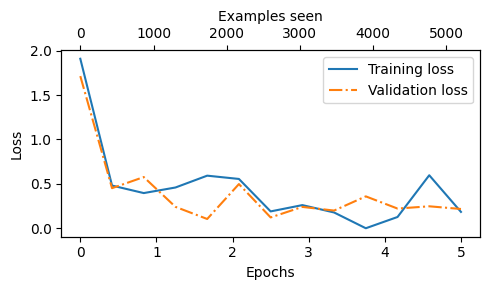

In [18]:
import matplotlib.pyplot as plt

def plot_values(
        epochs_seen, examples_seen, train_values, val_values,
        label="loss"
):
    fig, ax1 = plt.subplots(figsize=(5,3))
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_values, alpha=0)
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

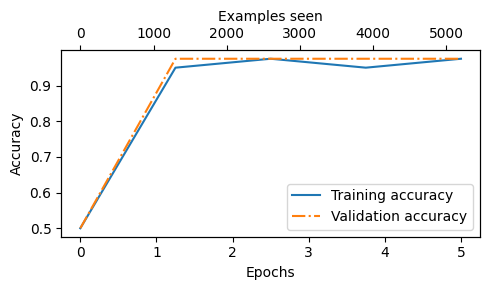

In [19]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(
    epochs_tensor, examples_seen_tensor, train_accs, val_accs,
    label="accuracy"
)

In [20]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)


print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 97.79%
Validation accuracy: 97.32%
Test accuracy: 94.00%


### Qualitative

In [21]:
def classify_review(
        text,model,tokenizer,device,max_length=None,pad_token_id=50256
):
    model.eval()
    input_ids=tokenizer.encode(text)
    supported_context_length = model.pos_emb.weight.shape[0]

    input_ids = input_ids[:min(max_length, supported_context_length)]
    input_ids += [pad_token_id] * (max_length - len(input_ids))

    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0)

    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]
    predicted_label = torch.argmax(logits, dim=-1).item()
    return "spam" if predicted_label == 1 else "ham"


In [22]:
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

print(classify_review(
    text_1, model, tokenizer, device, max_length=train_dataset.max_length
))

spam


In [23]:
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(classify_review(
    text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

ham


### Comments

As expected, in this case training time took longer and we got comparable performance to the fine-tuning without LoRA. Training time took longer because of the extra computation (now we do an extra xAB op at every linear layer, which accumulates computation time), but our memory requirements are much lower which is advantageous especially with an optimizer like AdamW, that holds multiple values in its state per parameter it is optimizing. Also, in larger models, this added forward pass can be negligible compared to a lot of costly backprops.